### Run models

In [ ]:
from ODE_hodgkinhuxley import Parameters, hodgkin_huxley, M_inf, N_inf
from ODE_morrislecar import morris_lecar
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve

In [3]:
#Parameters for both models set to be the same for comparison, taken from Morris-Lecar paper

params = Parameters(gL = 2, gCa = 4, gK = 8, 
                    VL = - 50, VCa = 100, VK = -70,
                    lambda_M_max = 1, lambda_N_max = 0.1, 
                    V1 = 0, V2 = 15, V3 = 10, V4 = 10, 
                    C = 20)

V0 = -50
M0 = M_inf(V0, params.V1, params.V2)
N0 = N_inf(V0, params.V3, params.V4)
t_span = (0, 300)
t_eval = np.linspace(*t_span, 3000)
print("Initial conditions: V0 =", V0, "M0 =", M0, "N0 =", N0)

Initial conditions: V0 = -50 M0 = 0.0012710162630813482 N0 = 6.144174602207286e-06


### Plot model for I=20, 40, 80, 100, 400

-38.3542047748348
19.391825850022517
7.551975774426274
8.25473136537097
17.291067639889185
-38.35403128237294
-28.806103437068888
26.130365878459184
8.228748996318048
17.27863581399694


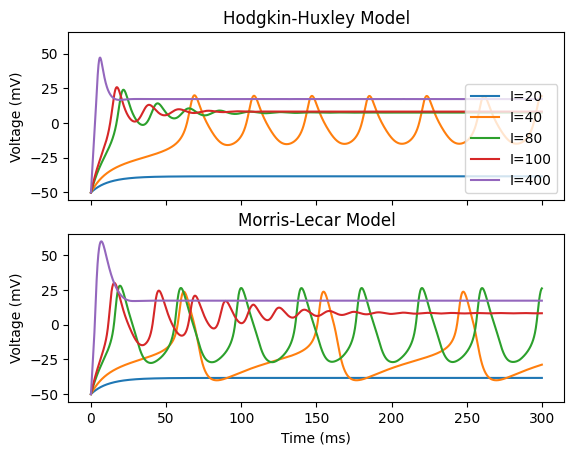

In [4]:
fig, ax = plt.subplots(2, 1, sharex=True, sharey=True)
for I in [20, 40, 80, 100, 400]:
    params.update(I=I)
    sol = solve_ivp(lambda t, y: hodgkin_huxley(y[0], y[1], y[2], t, params), t_span, [V0, M0, N0], t_eval=t_eval)
    print(sol.y[0][-1])
    ax[0].plot(sol.t, sol.y[0], label=f'I={I}')
ax[1].set_xlabel('Time (ms)')
ax[0].set_ylabel('Voltage (mV)')
ax[0].legend(loc='lower right')
for I in [20, 40, 80, 100, 400]:
    params.update(I=I)
    sol = solve_ivp(morris_lecar, t_span, [V0, N0], args=(params,), t_eval=t_eval)
    print(sol.y[0][-1])
    ax[1].plot(sol.t, sol.y[0], label=f'I={I}')
ax[1].set_ylabel('Voltage (mV)')
ax[0].set_title('Hodgkin-Huxley Model')
ax[1].set_title('Morris-Lecar Model')
plt.show()


### Phase planes

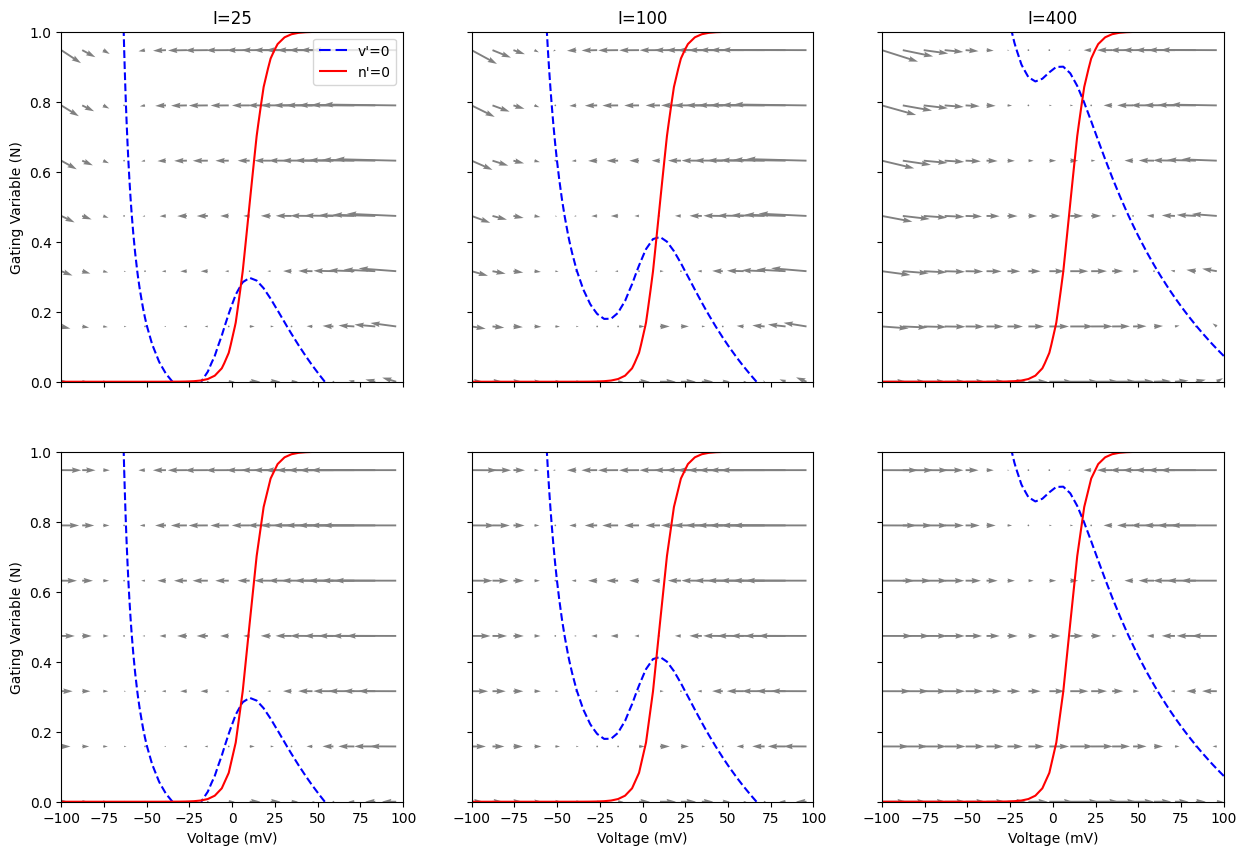

In [6]:
# Define the grid for the phase plane
xlo, xhi, xn = -100, 100, 50
ylo, yhi, yn = 0, 1, 20

xx, yy = np.meshgrid(np.linspace(xlo, xhi, xn), np.linspace(ylo, yhi, yn))
coords = np.c_[xx.ravel(), yy.ravel()]

# Initialize the figure
fig, ax = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(15,10))

# Compute nullclines for different current values
i=0
for I in [25, 100, 400]:
    i +=1
    params.update(I=I)
    ode_rhs = np.array([hodgkin_huxley(V, M_inf(V, params.V1, params.V2), N, 0, params) for V, N in coords])
    v_dot = ode_rhs[:, 0].reshape(xx.shape)
    n_dot = ode_rhs[:, 2].reshape(xx.shape)

    # Plot the nullclines
    CS1 = ax[0,i-1].contour(xx, yy, v_dot, levels=[0], colors='blue', linestyles='dashed')
    CS2 = ax[0,i-1].contour(xx, yy, n_dot, levels=[0], colors='red', linestyles='solid')
    lines, labels = CS1.legend_elements()
    lines2, labels2 = CS2.legend_elements()
    ax[0,i-1].quiver(xx[::3, ::3], yy[::3, ::3], v_dot[::3, ::3], n_dot[::3, ::3], color='gray')
ax[0,0].legend(lines + lines2, ["v'=0", "n'=0"], loc='upper right')

i=0
for I in [25, 100, 400]:
    i +=1
    params.update(I=I)
    ode_rhs = np.array([morris_lecar(0, coord, params) for coord in coords])
    v_dot = ode_rhs[:, 0].reshape(xx.shape)
    n_dot = ode_rhs[:, 1].reshape(xx.shape)

    # Plot the nullclines
    ax[1,i-1].contour(xx, yy, v_dot, levels=[0], colors='blue', linestyles='dashed')
    ax[1,i-1].contour(xx, yy, n_dot, levels=[0], colors='red', linestyles='solid')
    ax[1,i-1].quiver(xx[::3, ::3], yy[::3, ::3], v_dot[::3, ::3], n_dot[::3, ::3], color='gray')


# Customize the plot
ax[1,0].set_xlabel('Voltage (mV)')
ax[1,1].set_xlabel('Voltage (mV)')
ax[1,2].set_xlabel('Voltage (mV)')
ax[1,0].set_ylabel('Gating Variable (N)')
ax[0,0].set_ylabel('Gating Variable (N)')
ax[0,0].set_title('I=25')
ax[0,1].set_title('I=100')
ax[0,2].set_title('I=400')

plt.show()

#### Dynamics from V0 to limit

In [7]:
def find_limit_trend(ode_func, initial_state, params, t_span, t_eval, settle_time=1000):
    # Integrate for a while to let transients settle
    settle_t_span = (t_span[0], t_span[0] + settle_time)
    settle_sol = solve_ivp(ode_func, settle_t_span, initial_state, args=(params,), t_eval=np.linspace(*settle_t_span, 1000))

    # Use the final state as the new initial condition
    final_state = settle_sol.y[:, -1]

    # Integrate again to capture the limit cycle
    # Changed to use original initial_state to capture limit cycle trajectory as converges to point rather than cycle
    limit_cycle_sol = solve_ivp(ode_func, t_span, initial_state, args=(params,), t_eval=t_eval)
    return limit_cycle_sol

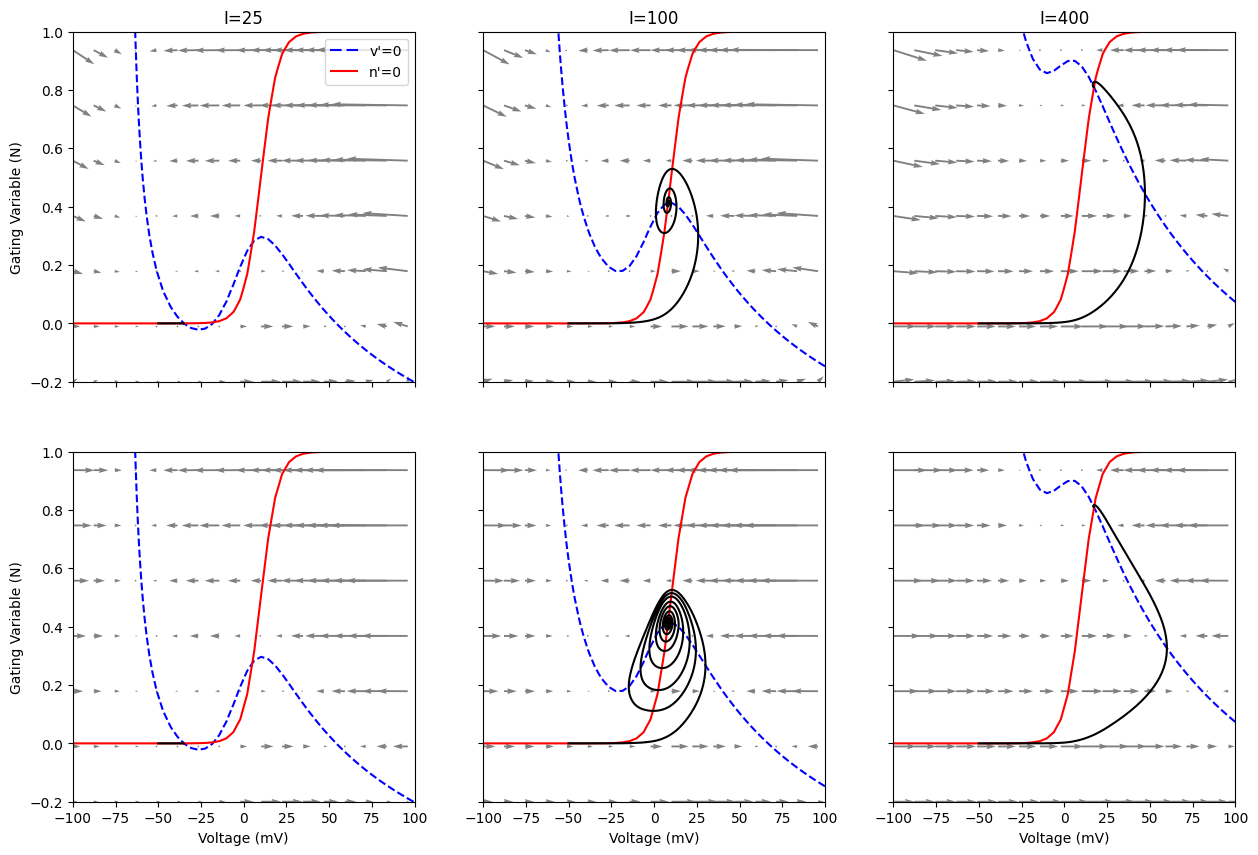

In [8]:
# Define the grid for the phase plane
xlo, xhi, xn = -100, 100, 50
ylo, yhi, yn = -0.2, 1, 20

xx, yy = np.meshgrid(np.linspace(xlo, xhi, xn), np.linspace(ylo, yhi, yn))
coords = np.c_[xx.ravel(), yy.ravel()]

# Initialize the figure
fig, ax = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(15,10))

# Compute nullclines for different current values
i=0
for I in [25, 100, 400]:
    i +=1
    params.update(I=I)
    ode_rhs = np.array([hodgkin_huxley(V, M_inf(V, params.V1, params.V2), N, 0, params) for V, N in coords])
    v_dot = ode_rhs[:, 0].reshape(xx.shape)
    n_dot = ode_rhs[:, 2].reshape(xx.shape)

    # Plot the nullclines
    CS1 = ax[0,i-1].contour(xx, yy, v_dot, levels=[0], colors='blue', linestyles='dashed')
    CS2 = ax[0,i-1].contour(xx, yy, n_dot, levels=[0], colors='red', linestyles='solid')
    lines, labels = CS1.legend_elements()
    lines2, labels2 = CS2.legend_elements()
    ax[0,i-1].quiver(xx[::3, ::3], yy[::3, ::3], v_dot[::3, ::3], n_dot[::3, ::3], color='gray')
ax[0,0].legend(lines + lines2, ["v'=0", "n'=0"], loc='upper right')

i=0
for I in [25, 100, 400]:
    i +=1
    params.update(I=I)
    ode_rhs = np.array([morris_lecar(0, coord, params) for coord in coords])
    v_dot = ode_rhs[:, 0].reshape(xx.shape)
    n_dot = ode_rhs[:, 1].reshape(xx.shape)

    # Plot the nullclines
    ax[1,i-1].contour(xx, yy, v_dot, levels=[0], colors='blue', linestyles='dashed')
    ax[1,i-1].contour(xx, yy, n_dot, levels=[0], colors='red', linestyles='solid')
    ax[1,i-1].quiver(xx[::3, ::3], yy[::3, ::3], v_dot[::3, ::3], n_dot[::3, ::3], color='gray')

t_span = (0, 200)
t_eval = np.linspace(*t_span, 2000)
i=0
for I in [25, 100, 400]:
    i += 1
    params.update(I=I)

    # Find and plot the limit cycle
    limit_cycle_sol = find_limit_trend(lambda t, y, p: hodgkin_huxley(y[0], y[1], y[2], t, p), [V0, M0, N0], params, t_span, t_eval)
    ax[0,i-1].plot(limit_cycle_sol.y[0], limit_cycle_sol.y[2], label=f'Limit Cycle (I={I})', color='black')

    limit_cycle_sol = find_limit_trend(lambda t, y, p: morris_lecar(t, y, p), [V0, N0], params, t_span, t_eval)
    ax[1,i-1].plot(limit_cycle_sol.y[0], limit_cycle_sol.y[1], label=f'Limit Cycle (I={I})', color='black')

# Customize the plot
ax[1,0].set_xlabel('Voltage (mV)')
ax[1,1].set_xlabel('Voltage (mV)')
ax[1,2].set_xlabel('Voltage (mV)')
ax[1,0].set_ylabel('Gating Variable (N)')
ax[0,0].set_ylabel('Gating Variable (N)')
ax[0,0].set_title('I=25')
ax[0,1].set_title('I=100')
ax[0,2].set_title('I=400')

plt.show()

### Plotting Limit Cycle

In [9]:
def find_limit_cycle(ode_func, initial_state, params, t_span, t_eval, settle_time=1000):
    # Integrate for a while to let transients settle
    settle_t_span = (t_span[0], t_span[0] + settle_time)
    settle_sol = solve_ivp(ode_func, settle_t_span, initial_state, args=(params,), t_eval=np.linspace(*settle_t_span, 1000))

    # Use the final state as the new initial condition
    final_state = settle_sol.y[:, -1]

    # Integrate again to capture the limit cycle
    # Changed to use original initial_state to capture limit cycle trajectory as converges to point rather than cycle
    limit_cycle_sol = solve_ivp(ode_func, t_span, final_state, args=(params,), t_eval=t_eval)
    return limit_cycle_sol

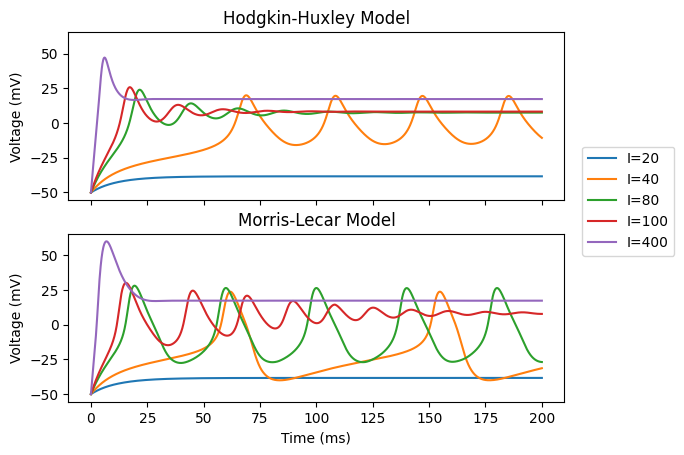

In [10]:
I_pos = [20, 40, 80, 100, 400]

fig, ax = plt.subplots(2, 1, sharex=True, sharey=True)
for I in I_pos:
    params.update(I=I)
    sol = solve_ivp(lambda t, y: hodgkin_huxley(y[0], y[1], y[2], t, params), t_span, [V0, M0, N0], t_eval=t_eval)
    ax[0].plot(sol.t, sol.y[0], label=f'I={I}')
ax[1].set_xlabel('Time (ms)')
ax[0].set_ylabel('Voltage (mV)')
fig.legend(bbox_to_anchor=(1, 0.4), loc='lower center')
for I in I_pos:
    params.update(I=I)
    sol = solve_ivp(morris_lecar, t_span, [V0, N0], args=(params,), t_eval=t_eval)
    ax[1].plot(sol.t, sol.y[0])
ax[1].set_ylabel('Voltage (mV)')
ax[0].set_title('Hodgkin-Huxley Model')
ax[1].set_title('Morris-Lecar Model')
plt.show()

### Model plot for range of different values of I

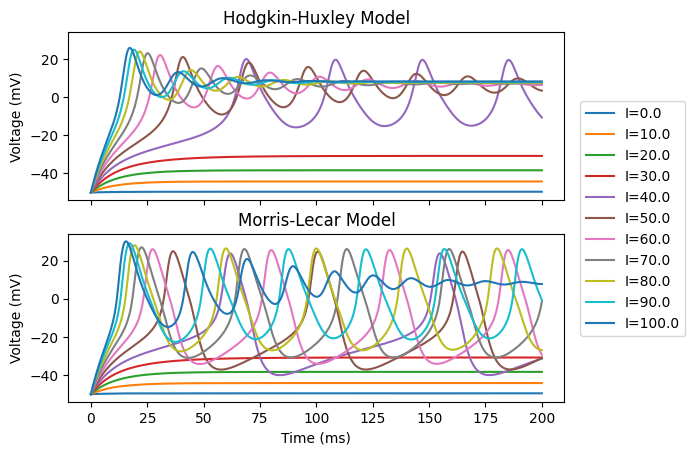

In [11]:
fig, ax = plt.subplots(2, 1, sharex=True, sharey=True)
V0 = -50
M0 = M_inf(V0, params.V1, params.V2)
N0 = N_inf(V0, params.V3, params.V4)
for I in np.linspace(0, 100, 11):
    params.update(I=I)
    sol_ml = solve_ivp(morris_lecar, t_span, [V0, N0], args=(params,), t_eval=t_eval)
    ax[1].plot(sol_ml.t, sol_ml.y[0], label=f'I={I:.1f}')
    sol_hh = solve_ivp(lambda t, y: hodgkin_huxley(y[0], y[1], y[2], t, params), t_span, [V0, M0, N0], t_eval=t_eval)
    ax[0].plot(sol_hh.t, sol_hh.y[0])
ax[1].set_xlabel('Time (ms)')
ax[0].set_ylabel('Voltage (mV)')
ax[1].set_ylabel('Voltage (mV)')
ax[0].set_title('Hodgkin-Huxley Model')
ax[1].set_title('Morris-Lecar Model')
fig.legend(loc='upper right', bbox_to_anchor=(1.1, 0.75))
plt.show()
    

6.3093674705713e-05
6.293493890738938e-05
0.24060079580033977
0.005626377902392108
0.37995778636692723
0.10782490604925908
0.41350377004324324
0.41256337945274846


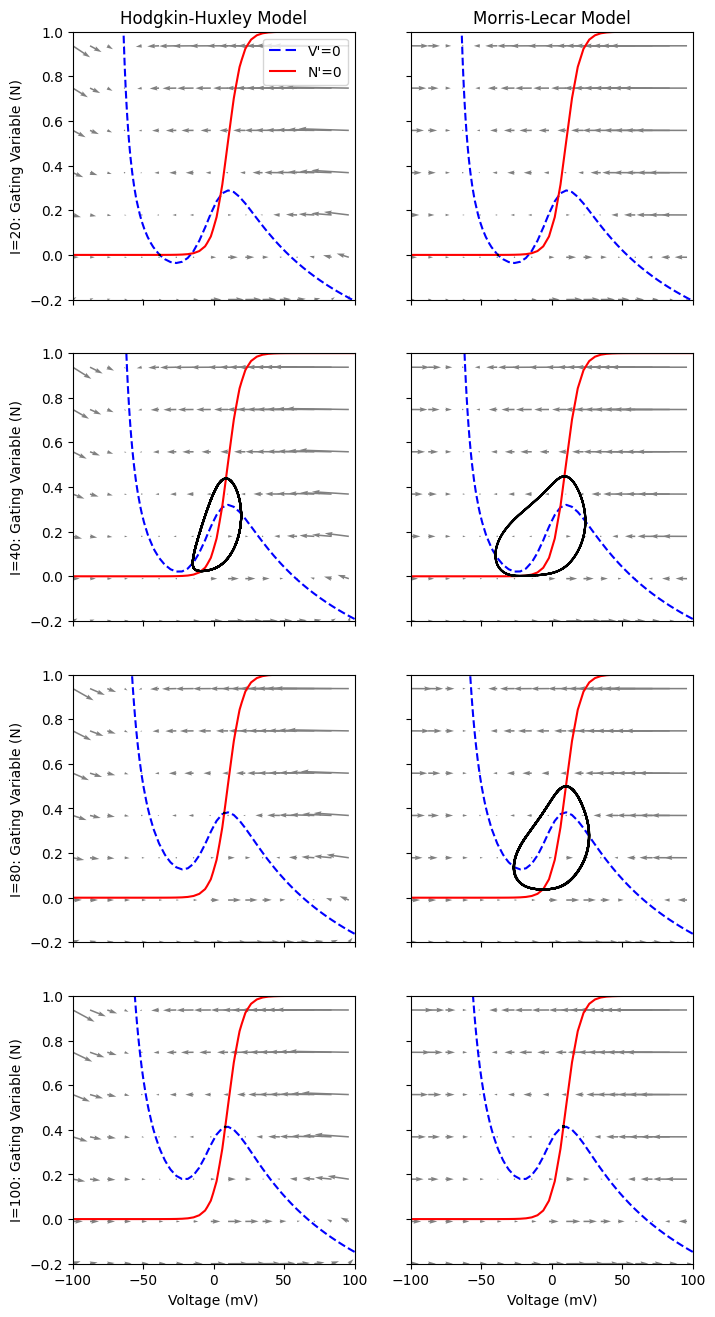

In [12]:
I_pos = [20, 40, 80, 100]

V0 = -50
M0 = M_inf(V0, params.V1, params.V2)
N0 = N_inf(V0, params.V3, params.V4)

# Define the grid for the phase plane
xlo, xhi, xn = -100, 100, 50
ylo, yhi, yn = -0.2, 1, 20

xx, yy = np.meshgrid(np.linspace(xlo, xhi, xn), np.linspace(ylo, yhi, yn))
coords = np.c_[xx.ravel(), yy.ravel()]

# Initialize the figure
fig, ax = plt.subplots(4, 2, sharex=True, sharey=True, figsize=(8,16))

# Compute nullclines for different current values
i=0
for I in I_pos:
    i +=1
    params.update(I=I)
    ode_rhs = np.array([hodgkin_huxley(V, M_inf(V, params.V1, params.V2), N, 0, params) for V, N in coords])
    v_dot = ode_rhs[:, 0].reshape(xx.shape)
    n_dot = ode_rhs[:, 2].reshape(xx.shape)

    # Plot the nullclines
    CS1 = ax[i-1,0].contour(xx, yy, v_dot, levels=[0], colors='blue', linestyles='dashed')
    CS2 = ax[i-1,0].contour(xx, yy, n_dot, levels=[0], colors='red', linestyles='solid')
    lines, labels = CS1.legend_elements()
    lines2, labels2 = CS2.legend_elements()
    ax[i-1,0].quiver(xx[::3, ::3], yy[::3, ::3], v_dot[::3, ::3], n_dot[::3, ::3], color='gray')
ax[0,0].legend(lines + lines2, ["V'=0", "N'=0"], loc='upper right')

i=0
for I in I_pos:
    i +=1
    params.update(I=I)
    ode_rhs = np.array([morris_lecar(0, coord, params) for coord in coords])
    v_dot = ode_rhs[:, 0].reshape(xx.shape)
    n_dot = ode_rhs[:, 1].reshape(xx.shape)

    # Plot the nullclines
    ax[i-1,1].contour(xx, yy, v_dot, levels=[0], colors='blue', linestyles='dashed')
    ax[i-1,1].contour(xx, yy, n_dot, levels=[0], colors='red', linestyles='solid')
    ax[i-1,1].quiver(xx[::3, ::3], yy[::3, ::3], v_dot[::3, ::3], n_dot[::3, ::3], color='gray')

t_span = (0, 300)
t_eval = np.linspace(*t_span, 2000)
i=0
for I in I_pos:
    i += 1
    params.update(I=I)

    # Find and plot the limit cycle
    limit_cycle_sol = find_limit_cycle(lambda t, y, p: hodgkin_huxley(y[0], y[1], y[2], t, p), [V0, M0, N0], params, t_span, t_eval)
    ax[i-1,0].plot(limit_cycle_sol.y[0], limit_cycle_sol.y[2], label=f'Limit Cycle (I={I})', color='black')
    print(limit_cycle_sol.y[2][1000])

    limit_cycle_sol = find_limit_cycle(lambda t, y, p: morris_lecar(t, y, p), [V0, N0], params, t_span, t_eval, settle_time=10000)
    ax[i-1,1].plot(limit_cycle_sol.y[0], limit_cycle_sol.y[1], label=f'Limit Cycle (I={I})', color='black')
    print(limit_cycle_sol.y[1][1000])

# Customize the plot
ax[-1,0].set_xlabel('Voltage (mV)')
ax[-1,1].set_xlabel('Voltage (mV)')
ax[0,0].set_ylabel('I=20: Gating Variable (N)')
ax[1,0].set_ylabel('I=40: Gating Variable (N)')
ax[2,0].set_ylabel('I=80: Gating Variable (N)')
ax[3,0].set_ylabel('I=100: Gating Variable (N)')
ax[0,0].set_title('Hodgkin-Huxley Model')
ax[0,1].set_title('Morris-Lecar Model')


plt.show()

-28.420899187353513
-26.629303317202037
-22.994657419958706
-4.953207061128085
-15.248291980862644
-28.40580661725381
-26.561539950972303
-22.095545002680417
-41.318354099744084
-32.18108379915439


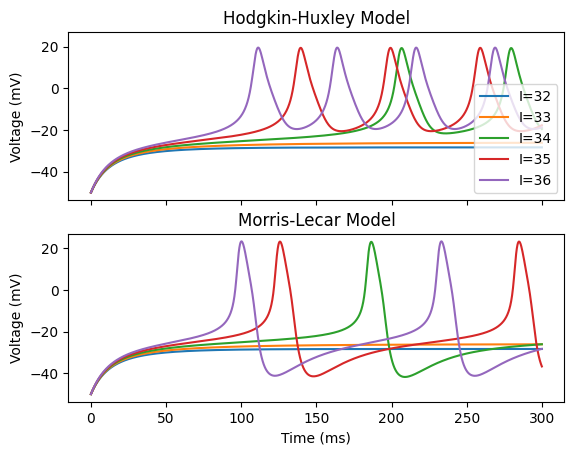

In [13]:
fig, ax = plt.subplots(2, 1, sharex=True, sharey=True)
for I in [32, 33, 34, 35, 36]:
    params.update(I=I)
    sol = solve_ivp(lambda t, y: hodgkin_huxley(y[0], y[1], y[2], t, params), t_span, [V0, M0, N0], t_eval=t_eval)
    print(sol.y[0][1000])
    ax[0].plot(sol.t, sol.y[0], label=f'I={I}')
ax[1].set_xlabel('Time (ms)')
ax[0].set_ylabel('Voltage (mV)')
ax[0].legend(loc='lower right')
for I in [32, 33, 34, 35, 36]:
    params.update(I=I)
    sol = solve_ivp(morris_lecar, t_span, [V0, N0], args=(params,), t_eval=t_eval)
    print(sol.y[0][1000])
    ax[1].plot(sol.t, sol.y[0], label=f'I={I}')
ax[1].set_ylabel('Voltage (mV)')
ax[0].set_title('Hodgkin-Huxley Model')
ax[1].set_title('Morris-Lecar Model')
plt.show()

### Demonstrating Bistability

-25.15374652599628
7.882484962490131
-26.604512035262623


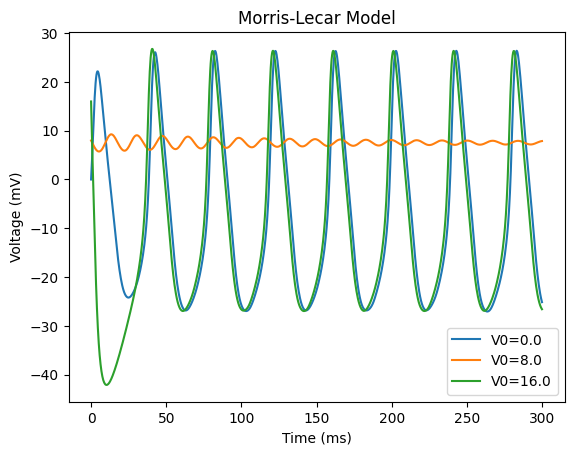

In [54]:
I = 80
t_span = (0, 300)
t_eval = np.linspace(*t_span, 1000)
params.update(I=I)
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True)
V0 = 8
ax.set_xlabel('Time (ms)')
for V0 in np.linspace(0, 16, 3):
    M0 = M_inf(V0, params.V1, params.V2)
    N0 = N_inf(V0, params.V3, params.V4)
    sol = solve_ivp(morris_lecar, t_span, [V0, N0], args=(params,), t_eval=t_eval)
    print(sol.y[0][-1])
    ax.plot(sol.t, sol.y[0], label=f'V0={V0}')
ax.set_ylabel('Voltage (mV)')
ax.set_title('Hodgkin-Huxley Model')
ax.set_title('Morris-Lecar Model')
ax.legend(loc='lower right')
plt.show()


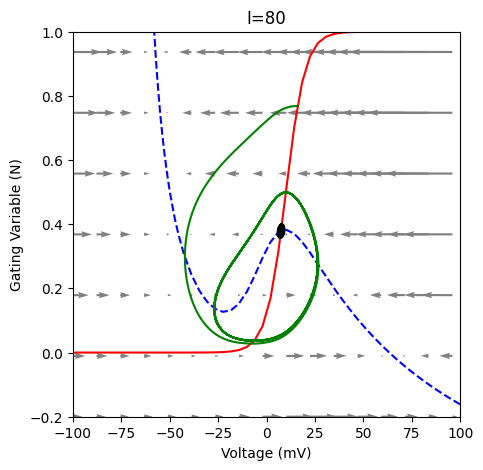

In [53]:
params.update(I=80)

V0 = 8
M0 = M_inf(V0, params.V1, params.V2)
N0 = N_inf(V0, params.V3, params.V4)
t_span = (0, 300)
t_eval = np.linspace(*t_span, 1000)
# Define the grid for the phase plane
xlo, xhi, xn = -100, 100, 50
ylo, yhi, yn = -0.2, 1, 20

xx, yy = np.meshgrid(np.linspace(xlo, xhi, xn), np.linspace(ylo, yhi, yn))
coords = np.c_[xx.ravel(), yy.ravel()]

# Initialize the figure
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(5,5))

i=0
for I in [80]:
    i +=1
    params.update(I=I)
    ode_rhs = np.array([morris_lecar(0, coord, params) for coord in coords])
    v_dot = ode_rhs[:, 0].reshape(xx.shape)
    n_dot = ode_rhs[:, 1].reshape(xx.shape)

    # Plot the nullclines
    ax.contour(xx, yy, v_dot, levels=[0], colors='blue', linestyles='dashed')
    ax.contour(xx, yy, n_dot, levels=[0], colors='red', linestyles='solid')
    ax.quiver(xx[::3, ::3], yy[::3, ::3], v_dot[::3, ::3], n_dot[::3, ::3], color='gray')

t_span = (0, 200)
t_eval = np.linspace(*t_span, 2000)
i=0
for I in [80]:
    i += 1
    params.update(I=I)

    limit_cycle_sol = find_limit_trend(lambda t, y, p: morris_lecar(t, y, p), [V0, N0], params, t_span, t_eval)
    ax.plot(limit_cycle_sol.y[0], limit_cycle_sol.y[1], label=f'Limit Cycle (I={I})', color='black')

    V0 = 16
    M0 = M_inf(V0, params.V1, params.V2)
    N0 = N_inf(V0, params.V3, params.V4)

    limit_cycle_sol = find_limit_trend(lambda t, y, p: morris_lecar(t, y, p), [V0, N0], params, t_span, t_eval)
    ax.plot(limit_cycle_sol.y[0], limit_cycle_sol.y[1], label=f'Limit Cycle (I={I})', color='green')

# Customize the plot
ax.set_ylabel('Gating Variable (N)')
ax.set_xlabel('Voltage (mV)')
ax.set_title('I=80')


plt.show()